In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df.job_posted_date)

In [41]:
df_usa = df[df['job_country']== 'United States'].copy()
df_usa['job_posted_month'] = df_usa['job_posted_date'].dt.strftime('%B')
df_usa_pivot = df_usa.pivot_table( index = 'job_posted_month',
                                 columns = 'job_title_short',
                                 aggfunc = 'size')
df_usa_pivot.reset_index(inplace = True)
df_usa_pivot['month_no.'] = pd.to_datetime(df_usa_pivot['job_posted_month'], format = '%B')
df_usa_pivot['month_no.'] = df_usa_pivot['month_no.'].dt.month
df_usa_pivot.sort_values(by = 'month_no.', ascending = True, inplace = True )
df_usa_pivot.set_index('job_posted_month', inplace = True)
df_usa_pivot = df_usa_pivot.drop(columns = 'month_no.')


In [42]:
df_usa_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,527,36,8494,2655,6915,60,1544,773,1552,114
February,447,24,6124,3060,4956,56,1258,878,1127,90
March,438,19,6218,3183,4779,59,1114,829,1150,115
April,565,40,6049,2801,4867,51,1025,781,991,112
May,279,20,4993,2976,4377,49,839,746,914,90
June,446,32,5683,2893,4645,48,1009,812,1033,93
July,581,39,5201,2570,4876,65,883,747,1095,153
August,903,39,6634,3269,6318,68,1186,903,1515,194
September,897,50,4639,3224,4568,113,805,775,1014,228


In [43]:
df_us_software_pivot = pd.read_csv("https://lukeb.co/software_csv", index_col = 'job_posted_month')
df_us_merged = df_usa_pivot.merge(df_us_software_pivot, on = 'job_posted_month')



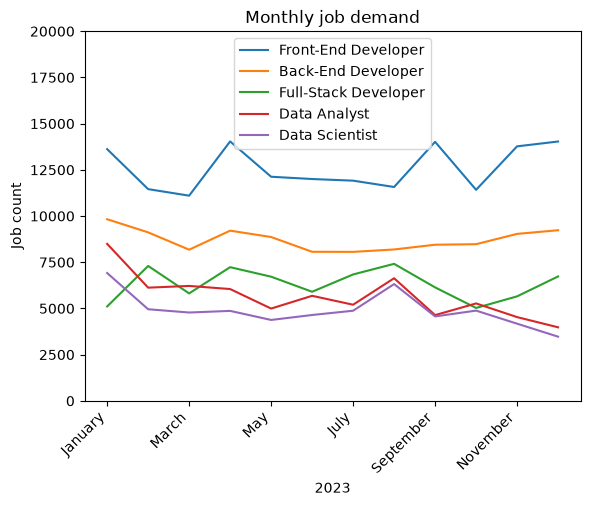

In [48]:
top_5 = df_us_merged.sum().sort_values(ascending = False).head().index.to_list()
df_us_merged[top_5].plot(kind = 'line')
plt.xticks(rotation = 45, ha = 'right')
plt.xlabel('2023')
plt.ylabel('Job count')
plt.title('Monthly job demand')
plt.ylim(0,20000)
plt.legend()
plt.show()
